Importing Dataset

In [2]:
!pip install -q kaggle

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dheerajnigam","key":"85aa92b5a26aab5a6729958f1453b8de"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d qinglizeng1997/uavids-2025

Dataset URL: https://www.kaggle.com/datasets/qinglizeng1997/uavids-2025
License(s): ODbL-1.0
100% 5.32M/5.32M [00:00<00:00, 49.7MB/s]



In [7]:
!unzip -q uavids-2025.zip

In [8]:
import os
os.listdir()

['.config', 'UAVIDS-2025.csv', 'uavids-2025.zip', 'kaggle.json', 'sample_data']

Preprocessing

In [9]:
import pandas as pd
df = pd.read_csv("UAVIDS-2025.csv")
df.head()

,FlowID,FlowDuration/s,SrcAddr,SrcPort,DstAddr,DstPort,Protocol,TxPackets,RxPackets,LostPackets,...,RxPacketRate/s,TxByteRate/s,RxByteRate/s,MeanDelay/s,MeanJitter/s,Throughput/Kbps,MeanPacketSize,PacketDropRate,AverageHopCount,label
0,1,175.007,192.168.0.150,9,192.168.0.16,9,UDP,251,215,36,...,1.22853,109.002,93.3679,0.022152,0.024406,0.746943,76,0.143426,0.074419,Sybil Attack
1,2,175.008,192.168.0.150,9,192.168.0.19,9,UDP,251,223,28,...,1.27423,109.001,96.8411,0.019637,0.018678,0.774729,76,0.111554,0.053812,Sybil Attack
2,3,175.010,192.168.0.150,9,192.168.0.24,9,UDP,251,224,27,...,1.27993,108.999,97.2744,0.023701,0.023917,0.778195,76,0.107570,0.044643,Sybil Attack
3,4,175.014,192.168.0.150,9,192.168.0.34,9,UDP,251,212,39,...,1.21133,108.997,92.0614,0.034014,0.025408,0.736491,76,0.155378,0.033019,Sybil Attack
4,5,175.017,192.168.0.150,9,192.168.0.39,9,UDP,251,215,36,...,1.22845,108.995,93.3623,0.034396,0.024933,0.746899,76,0.143426,0.009302,Sybil Attack


In [10]:
df = df.drop(['Protocol', 'FlowID'], axis = 1)

In [11]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122171 entries, 0 to 122170
Data columns (total 21 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   FlowDuration/s   122171 non-null  float64
 1   SrcAddr          122171 non-null  object 
 2   SrcPort          122171 non-null  int64  
 3   DstAddr          122171 non-null  object 
 4   DstPort          122171 non-null  int64  
 5   TxPackets        122171 non-null  int64  
 6   RxPackets        122171 non-null  int64  
 7   LostPackets      122171 non-null  int64  
 8   TxBytes          122171 non-null  int64  
 9   RxBytes          122171 non-null  int64  
 10  TxPacketRate/s   122171 non-null  float64
 11  RxPacketRate/s   122171 non-null  float64
 12  TxByteRate/s     122171 non-null  float64
 13  RxByteRate/s     122171 non-null  float64
 14  MeanDelay/s      122171 non-null  float64
 15  MeanJitter/s     122171 non-null  float64
 16  Throughput/Kbps  122171 non-null  floa

np.int64(8205)

Encoding

In [12]:
from sklearn.preprocessing import LabelEncoder

src_encoder = LabelEncoder()
dst_encoder = LabelEncoder()
label_encoder = LabelEncoder()

df['SrcAddr'] = src_encoder.fit_transform(df['SrcAddr'])
df['DstAddr'] = dst_encoder.fit_transform(df['DstAddr'])
df['label'] = label_encoder.fit_transform(df['label'])

df.head()

,FlowDuration/s,SrcAddr,SrcPort,DstAddr,DstPort,TxPackets,RxPackets,LostPackets,TxBytes,RxBytes,...,RxPacketRate/s,TxByteRate/s,RxByteRate/s,MeanDelay/s,MeanJitter/s,Throughput/Kbps,MeanPacketSize,PacketDropRate,AverageHopCount,label
0,175.007,62,9,85,9,251,215,36,19076,16340,...,1.22853,109.002,93.3679,0.022152,0.024406,0.746943,76,0.143426,0.074419,3
1,175.008,62,9,118,9,251,223,28,19076,16948,...,1.27423,109.001,96.8411,0.019637,0.018678,0.774729,76,0.111554,0.053812,3
2,175.010,62,9,135,9,251,224,27,19076,17024,...,1.27993,108.999,97.2744,0.023701,0.023917,0.778195,76,0.107570,0.044643,3
3,175.014,62,9,146,9,251,212,39,19076,16112,...,1.21133,108.997,92.0614,0.034014,0.025408,0.736491,76,0.155378,0.033019,3
4,175.017,62,9,151,9,251,215,36,19076,16340,...,1.22845,108.995,93.3623,0.034396,0.024933,0.746899,76,0.143426,0.009302,3


In [13]:
for i, attack in enumerate(label_encoder.classes_):
    print(i, "=", attack)

0 = Blackhole Attack
1 = Flooding Attack
2 = Normal Traffic
3 = Sybil Attack
4 = Wormhole Attack


In [14]:
label_mapping = dict(enumerate(label_encoder.classes_))
print(label_mapping)

{0: 'Blackhole Attack', 1: 'Flooding Attack', 2: 'Normal Traffic', 3: 'Sybil Attack', 4: 'Wormhole Attack'}


Splitting

In [15]:
X = df.drop('label',axis=1)
y = df['label']

print('X shape', X.shape)
print('y shape', y.shape)

X shape (122171, 20)
y shape (122171,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(97736, 20)
(24435, 20)
(97736,)
(24435,)


#All Models Training

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---- Consistent stratified split (used by all 3 models) ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---- 1. Decision Tree ----
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

# ---- 2. Random Forest ----
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# ---- 3. XGBoost ----
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

=== Decision Tree ===
Accuracy: 0.9384489461837529
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      5222
           1       0.99      0.98      0.99      3945
           2       0.99      0.98      0.98      5235
           3       0.99      1.00      0.99      4816
           4       0.86      0.86      0.86      5217

    accuracy                           0.94     24435
   macro avg       0.94      0.94      0.94     24435
weighted avg       0.94      0.94      0.94     24435

=== Random Forest ===
Accuracy: 0.9513812154696133
              precision    recall  f1-score   support

           0       0.93      0.87      0.90      5222
           1       1.00      0.99      0.99      3945
           2       0.99      0.99      0.99      5235
           3       0.99      1.00      1.00      4816
           4       0.87      0.92      0.89      5217

    accuracy                           0.95     24435
   macro avg       0.95      

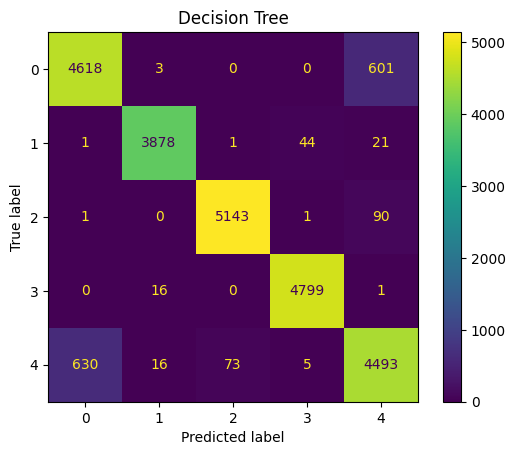

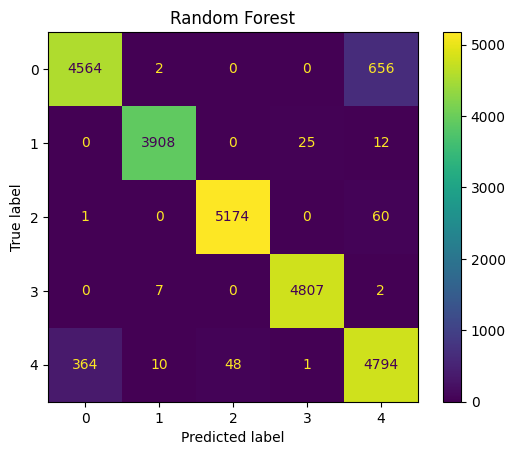

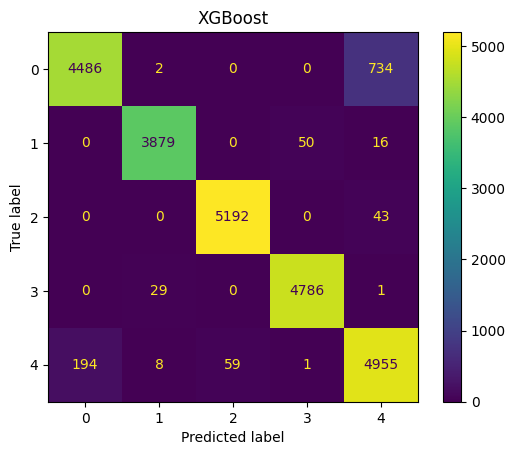

In [34]:
for name, preds in [("Decision Tree", y_pred_dt), ("Random Forest", y_pred_rf), ("XGBoost", y_pred_xgb)]:
    ConfusionMatrixDisplay.from_predictions(y_test, preds)
    plt.title(name)
    plt.show()

#Esemble Learning

In [35]:
import numpy as np
from scipy import stats

# Stack predictions from all 3 models: shape (n_models, n_samples)
all_preds = np.array([y_pred_dt, y_pred, y_pred_xgb])  # y_pred = RF's prediction from your notebook

# Majority vote across axis 0 (across the 3 models, for each sample)
hard_vote_pred, _ = stats.mode(all_preds, axis=0, keepdims=False)

print("Hard Voting Accuracy:", accuracy_score(y_test, hard_vote_pred))
print(classification_report(y_test, hard_vote_pred))

Hard Voting Accuracy: 0.9426232862696952
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      5222
           1       0.98      0.99      0.98      3945
           2       0.99      0.99      0.99      5235
           3       0.99      0.99      0.99      4816
           4       0.88      0.87      0.87      5217

    accuracy                           0.94     24435
   macro avg       0.95      0.95      0.95     24435
weighted avg       0.94      0.94      0.94     24435



In [36]:
import numpy as np

# Get probability outputs from all 3 models (shape: n_samples x n_classes)
proba_dt = dt_model.predict_proba(X_test)
proba_rf = rf_model.predict_proba(X_test)
proba_xgb = xgb_model.predict_proba(X_test)

# Average the probabilities across the 3 models
avg_proba = (proba_dt + proba_rf + proba_xgb) / 3

# Final prediction = class with highest averaged probability
soft_vote_pred = np.argmax(avg_proba, axis=1)

print("Soft Voting Accuracy:", accuracy_score(y_test, soft_vote_pred))
print(classification_report(y_test, soft_vote_pred))

Soft Voting Accuracy: 0.9462656026191938
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      5222
           1       0.99      0.99      0.99      3945
           2       0.99      0.99      0.99      5235
           3       0.99      1.00      1.00      4816
           4       0.87      0.89      0.88      5217

    accuracy                           0.95     24435
   macro avg       0.95      0.95      0.95     24435
weighted avg       0.95      0.95      0.95     24435



In [37]:
# Weights based on each model's overall accuracy (adjust these based on your own results)
w_dt, w_rf, w_xgb = 0.30, 0.35, 0.35   # DT gets less say, RF and XGBoost get more

weighted_proba = (w_dt * proba_dt) + (w_rf * proba_rf) + (w_xgb * proba_xgb)
weighted_vote_pred = np.argmax(weighted_proba, axis=1)

print("Weighted Voting Accuracy:", accuracy_score(y_test, weighted_vote_pred))
print(classification_report(y_test, weighted_vote_pred))

Weighted Voting Accuracy: 0.9481072232453448
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      5222
           1       0.99      0.99      0.99      3945
           2       0.99      0.99      0.99      5235
           3       0.99      1.00      1.00      4816
           4       0.87      0.90      0.88      5217

    accuracy                           0.95     24435
   macro avg       0.95      0.95      0.95     24435
weighted avg       0.95      0.95      0.95     24435



In [38]:
# Weights based on each model's overall accuracy (adjust these based on your own results)
w_dt, w_rf, w_xgb = 0.15, 0.40, 0.45   # DT gets less say, RF and XGBoost get more

weighted_proba = (w_dt * proba_dt) + (w_rf * proba_rf) + (w_xgb * proba_xgb)
weighted_vote_pred = np.argmax(weighted_proba, axis=1)

print("Weighted Voting Accuracy:", accuracy_score(y_test, weighted_vote_pred))
print(classification_report(y_test, weighted_vote_pred))

Weighted Voting Accuracy: 0.9532228360957643
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      5222
           1       0.99      0.99      0.99      3945
           2       0.99      0.99      0.99      5235
           3       0.99      1.00      1.00      4816
           4       0.87      0.93      0.90      5217

    accuracy                           0.95     24435
   macro avg       0.96      0.96      0.96     24435
weighted avg       0.95      0.95      0.95     24435



In [39]:
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
import numpy as np

# Generate out-of-fold probability predictions for each base model on the TRAINING set
# This ensures no data leakage - each fold's predictions come from a model that never saw that fold
dt_oof = cross_val_predict(dt_model, X_train, y_train, cv=5, method='predict_proba')
rf_oof = cross_val_predict(rf_model, X_train, y_train, cv=5, method='predict_proba')
xgb_oof = cross_val_predict(xgb_model, X_train, y_train, cv=5, method='predict_proba')

# Stack these as meta-features: (n_samples, 3 models * 5 classes = 15 columns)
meta_X_train = np.hstack([dt_oof, rf_oof, xgb_oof])

# Meta-model learns how to combine the 3 models' probability outputs
meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(meta_X_train, y_train)

# For the actual test set, use each base model's normal (already-fitted) predict_proba
meta_X_test = np.hstack([proba_dt, proba_rf, proba_xgb])  # from your earlier code
stack_pred = meta_model.predict(meta_X_test)

print("Stacking Accuracy:", accuracy_score(y_test, stack_pred))
print(classification_report(y_test, stack_pred))

Stacking Accuracy: 0.9551053816247187
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      5222
           1       1.00      0.99      0.99      3945
           2       0.99      0.99      0.99      5235
           3       1.00      1.00      1.00      4816
           4       0.87      0.93      0.90      5217

    accuracy                           0.96     24435
   macro avg       0.96      0.96      0.96     24435
weighted avg       0.96      0.96      0.96     24435

